In [1]:
from funcions_labs import *
from IPython.display import display, Markdown
import numpy as np
import pandas as pd

# Pèndol de Pohl

informe realitzat per Oriol Codony Lleonart i Pol Marcote Vidal, Universitat de Barcelona

## Resum

...

## Resultats

Cal mencionar inicialment la incertesa sistemàtica usada en aquesta pràctica, $\delta \varphi = 1 \ u.a$.

In [2]:
dphi = 1
dt = 0.001

### Oscil·lacions esmorteïdes

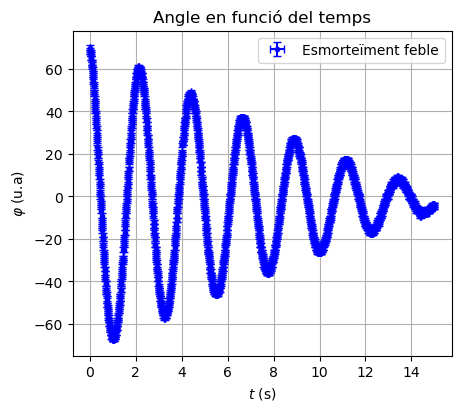

<Axes: title={'center': 'Angle en funció del temps'}, xlabel='$t$ (s)', ylabel='$\\varphi$ (u.a)'>

In [3]:
tfeb, phifeb = llegeix_dades("Esmfeb.txt", skip=1)

mostra_dades(
    tfeb, phifeb,
    incert_x=np.full_like(tfeb, dt),
    incert_y=np.full_like(phifeb, dphi),
    xlabel=r'$t$ (s)',
    ylabel=r'$\varphi$ (u.a)',
    titol='Angle en funció del temps',
    forma='.',
    label_dades='Esmorteïment feble',
    color="blue"
)

Figura 1: Representació de l'evolució de l'angle de deflexió $\varphi$ en funció del temps $t$, amb les seves respectives incerteses, en el cas de l'esmorteïment feble.

In [4]:
n0 = 5
ti0 = 2.122
dti0 = 0.00
tf0 = 13.409
dtf0 = 0.008

T0 = (tf0-ti0)/n0
dT0 = np.sqrt(dti0**2+dtf0**2)/n0
w0 = (2*np.pi)/T0
dw0 = (2*np.pi*dT0)/T0**2

dM("T_0 =" + format_resultat(T0, dT0) + " \ s")
dM("\omega_0 =" + format_resultat(w0, dw0) + " \ rad/s")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

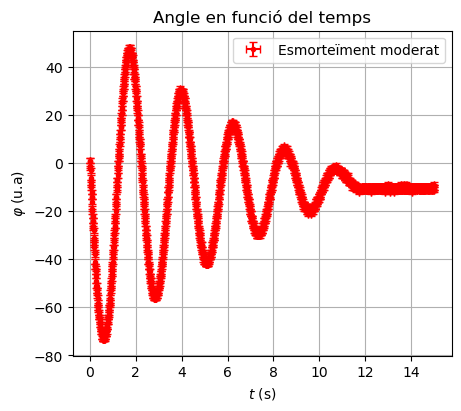

<Axes: title={'center': 'Angle en funció del temps'}, xlabel='$t$ (s)', ylabel='$\\varphi$ (u.a)'>

In [5]:
tesm, phiesm = llegeix_dades("Esm.txt", skip=1)

mostra_dades(
    tesm, phiesm,
    incert_x=np.full_like(tesm, dt),
    incert_y=np.full_like(phiesm, dphi),
    xlabel=r'$t$ (s)',
    ylabel=r'$\varphi$ (u.a)',
    titol='Angle en funció del temps',
    forma='.',
    label_dades='Esmorteïment moderat',
    color="red"
)

Figura 2: Representació de l'evolució de l'angle de deflexió $\varphi$ en funció del temps $t$, amb les seves respectives incerteses, en el cas d'un esmorteïment moderat.

In [6]:
n1 = 4
ti1 = 1.732
dti1 = 0.003
tf1 = 10.726
dtf1 = 0.008

T1 = (tf1-ti1)/n1
dT1 = np.sqrt(dti1**2+dtf1**2)/n1
w1 = (2*np.pi)/T1
dw1 = (2*np.pi*dT1)/T1**2

dM("T_1 =" + format_resultat(T1, dT1) + " \ s")
dM("\omega_1 =" + format_resultat(w1, dw1) + " \ rad/s")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
tn, phin = llegeix_dades("Maxmin.txt", skip=1)
dtn = np.array([0.007, 0.003, 0.008, 0.011, 0.008, 0.006, 0.010, 0.008, 0.011, 0.008])
dphin = np.full_like(dtn, dphi)

def taula_dades1(t, dt, phi, dphi):
    rows = []
    rows.append(r"| $t_n$ (s) | $\delta t_n$ (s) | $\varphi_n$ (u.a) | $\delta \varphi_n$ (u.a) |")
    rows.append(r"|:---:|:---:|:---:|:---:|")

    for i in range(len(t)):
        rows.append(
            f"| {t[i]:.3f} | {dt[i]:.3f} | {phi[i]:.0f} | {dphi[i]:.0f} |"
        )

    display(Markdown("\n".join(rows)))

taula_dades1(tn, dtn, phin, dphin)

| $t_n$ (s) | $\delta t_n$ (s) | $\varphi_n$ (u.a) | $\delta \varphi_n$ (u.a) |
|:---:|:---:|:---:|:---:|
| 0.604 | 0.007 | -73 | 1 |
| 1.732 | 0.003 | 48 | 1 |
| 2.853 | 0.008 | -56 | 1 |
| 3.935 | 0.011 | 31 | 1 |
| 5.102 | 0.008 | -42 | 1 |
| 6.204 | 0.006 | 17 | 1 |
| 7.326 | 0.010 | -30 | 1 |
| 8.462 | 0.008 | 7 | 1 |
| 9.647 | 0.011 | -21 | 1 |
| 10.726 | 0.008 | -1 | 1 |

Taula 1: Dades corresponents al temps $t_n$ i l'amplitud $\varphi_n$ en cada màxim o mínim de la figura 2, amb les seves respectives incerteses, la del temps usant l'expressió (*) i per l'amplitud és l'error sistemàtic $\delta \varphi$ mencionat al principi d'aquesta secció.

Ara es farà servir la fórmula (expressió 4 del guió) per determinar la constant d'esmorteïment $\beta$, amb la següent expressió i el seu respectiu ajust lineal:

$$
ln|\varphi_n| = - \beta \ t + ln(\varphi_0)
$$

on la incertesa del logaritme de l'amplitud és aquesta:

$$
\delta (ln|\varphi_n|) = \frac{\delta \varphi}{|\varphi_n|}
$$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

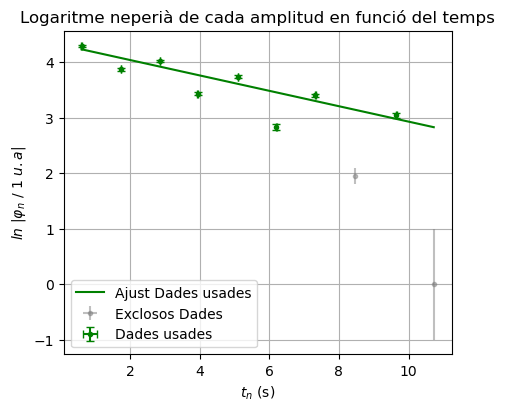

<Axes: title={'center': 'Logaritme neperià de cada amplitud en funció del temps'}, xlabel='$t_n$ (s)', ylabel='$ln \\ |\\varphi_n \\ / \\ 1 \\ u.a|$'>

In [27]:
lnphin = np.log(abs(phin))
dlnphin = abs(dphi/phin)

mostra_dades(
    tn, lnphin,
    incert_x=dtn,
    incert_y=np.full_like(lnphin, dlnphin),
    funcio_model=model_lineal,
    xlabel=r'$t_n$ (s)',
    ylabel=r'$ln \ |\varphi_n \ / \ 1 \ u.a|$',
    titol='Logaritme neperià de cada amplitud en funció del temps',
    forma='.',
    color="green",
    exclude=[7, 9]
)

Figura 3: Representació de l'evolució del logaritme neperià de l'amplitud de cada màxim o mínim $ln \ |\varphi_n / 1 \ u.a|$ en funció del temps $t_n$, amb les seves barres d'error. S'ha decidit no considerar dos punts que no estan alineats amb la resta.

Amb això, es té que el pendent de la regressió és la constant d'esmorteïment $\beta$ amb signe oposat.

$$
\beta = (139 \pm 4) \times 10^{-3} \ s^{-1}
$$

In [15]:
B = 0.139
dB = 0.004

Gràcies a l'expressió (expressió 5 del guió), es pot determinar el valor del decrement logarítmic $\lambda$

$$
\lambda = \beta \ T_1
$$

El seu error és el següent:

$$
\delta \lambda = \sqrt{(\beta \ \delta T_1)^2+(T_1 \ \delta \beta)^2}
$$

In [68]:
l = B*T1
dl = np.sqrt((B*dT1)**2+(T1*dB)**2)

dM("\lambda =" + format_resultat(l, dl))

<IPython.core.display.Math object>

...

### Oscil·lacions forçades

In [11]:
Pa, Ta, dTa, phia = llegeix_dades("ress.txt", skip=1)

wa = (2*np.pi)/Ta
dwa = (2*np.pi*dTa)/Ta**2
dphia = np.full_like(phia, dphi)

def taula_dades2(P, T, dT, w, dw, phi, dphi):
    rows = []
    rows.append(r"| $P$ (%) | $T_a$ (s) | $\delta T_a$ (s) | $\omega_a$ (rad/s) | $\delta \omega_a$ (rad/s) | $\varphi_a$ (u.a) | $\delta \varphi_a$ (u.a) |")
    rows.append(r"|:---:|:---:|:---:|:---:|:---:|:---:|:---:|")

    for i in range(len(Pa)):
        rows.append(
            f"| {P[i]:.0f} | {T[i]:.2f} | {dT[i]:.2f} | {w[i]:.2f} | {dw[i]:.2f} | {phi[i]:.0f} | {dphi[i]:.0f} |"
        )

    display(Markdown("\n".join(rows)))

taula_dades2(Pa, Ta, dTa, wa, dwa, phia, dphia)

| $P$ (%) | $T_a$ (s) | $\delta T_a$ (s) | $\omega_a$ (rad/s) | $\delta \omega_a$ (rad/s) | $\varphi_a$ (u.a) | $\delta \varphi_a$ (u.a) |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 20 | 2.49 | 0.04 | 2.52 | 0.04 | 22 | 1 |
| 25 | 2.32 | 0.04 | 2.71 | 0.05 | 38 | 1 |
| 26 | 2.26 | 0.03 | 2.78 | 0.04 | 43 | 1 |
| 27 | 2.11 | 0.03 | 2.98 | 0.04 | 41 | 1 |
| 28 | 1.93 | 0.03 | 3.26 | 0.05 | 12 | 1 |
| 29 | 1.80 | 0.03 | 3.49 | 0.06 | 10 | 1 |
| 30 | 1.72 | 0.02 | 3.65 | 0.04 | 10 | 1 |
| 31 | 1.83 | 0.02 | 3.43 | 0.04 | 8 | 1 |
| 32 | 1.82 | 0.02 | 3.45 | 0.04 | 8 | 1 |
| 33 | 1.76 | 0.01 | 3.57 | 0.02 | 7 | 1 |
| 34 | 1.79 | 0.02 | 3.51 | 0.04 | 6 | 1 |
| 35 | 1.71 | 0.02 | 3.67 | 0.04 | 6 | 1 |
| 40 | 1.65 | 0.01 | 3.81 | 0.02 | 5 | 1 |
| 50 | 1.43 | 0.01 | 4.39 | 0.03 | 5 | 1 |
| 60 | 1.33 | 0.01 | 4.72 | 0.04 | 5 | 1 |
| 70 | 1.19 | 0.01 | 5.28 | 0.04 | 5 | 1 |
| 80 | 1.27 | 0.01 | 4.95 | 0.04 | 5 | 1 |

Taula 2: Dades corresponents a la potència del motor $P$, el període d'scil·lació $T_a$ i la seva incertesa $dT_a$, la freqüència $\omega_a$ i el seu error $\delta \omega_a$, tots calculats amb les expressions de l'inici de l'apartat, i l'amplitud d'oscil·lació $\varphi_a$ amb la seva incertesa sistemàtica $\delta \varphi$ determinada a l'inici d'aquesta part de l'informe.

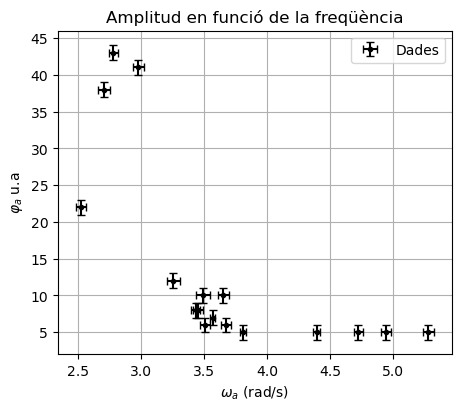

<Axes: title={'center': 'Amplitud en funció de la freqüència'}, xlabel='$\\omega_a$ (rad/s)', ylabel='$\\varphi_a$ u.a'>

In [13]:
mostra_dades(
    wa, phia,
    incert_x=dwa,
    incert_y=dphia,
    xlabel=r'$\omega_a$ (rad/s)',
    ylabel=r'$\varphi_a$ u.a',
    titol='Amplitud en funció de la freqüència',
    forma='.',
    color="black",
)

Figura 4: Representació de les dades de la taula 2 corresponents a l'amplitud d'oscil·lació en funció de la freqüència.

S'observa que es dona un pic quan la potència del motor és del 26%, corresponent a la freqüència de ressonància $\omega_r = 2.78 \pm 0.04 \ rad/s$.

Comparant $\omega_r = 2.78 \pm 0.04 \ rad/s$ amb $\omega_0 = 2.783 \pm 0.003 \ rad/s$ i $\omega_1 = 2.794 \pm 0.003 \ rad/s$, s'extreu que en tots dos casos són valors molt propers a la freqüència de ressonància, especialment la freqüència amb un esmorteïment feble.

D'acord amb l'expressió (fórmula de la freqüència de ressonància), el model teòric indica la següent relació esperada entre aquestes dues freqüències $\omega_i$ i la freqüència de ressonància $\omega_r$ és aquesta:

$$
\omega_{ri} = \sqrt{\omega_i^2-2 \beta^2}
$$

amb propagació d'errors, aquest valor té la següent incertesa:

$$
\delta \omega_{ri} = \sqrt{\frac{(\omega_i \ \delta \omega_i)^2+(2 \beta \ \delta \beta)^2}{\omega_i^2-2 \beta^2}}
$$

In [25]:
wr = wa[2]
dwr = dwa[2]

wr0 = np.sqrt(w0**2-2*B**2)
dwr0 = np.sqrt(((w0*dw0)**2+(2*B*dB)**2)/(w0**2-2*B**2))

wr1 = np.sqrt(w1**2-2*B**2)
dwr1 = np.sqrt(((w1*dw1)**2+(2*B*dB)**2)/(w1**2-2*B**2))

dM("\omega_{r0} =" + format_resultat(wr0, dwr0) + " \ rad/s")
dM("\omega_{r1} =" + format_resultat(wr1, dwr1) + " \ rad/s")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Ara s'analitza la discrepància, on

$$
d_i = |\omega_r - \omega_{ri}|
$$

i també

$$
\delta_i = \sqrt{\omega_r^2+\omega_{ri}^2}
$$

In [23]:
d0 = abs(wr0-wr)
d1 = abs(wr1-wr)

dd0 = np.sqrt(dwr**2+dwr0**2)
dd1 = np.sqrt(dwr**2+dwr1**2)

dM("d_0 =" + format_resultat(d0, 0) + " \ rad/s")
dM("d_1 =" + format_resultat(d1, 0) + " \ rad/s")
dM("\delta_0 =" + format_resultat(dd0, 0) + " \ rad/s")
dM("\delta_1 =" + format_resultat(dd1, 0) + " \ rad/s")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Conclusions

...